# Tidyverse and Dplyr for data wrangling

### Dplyr verbs

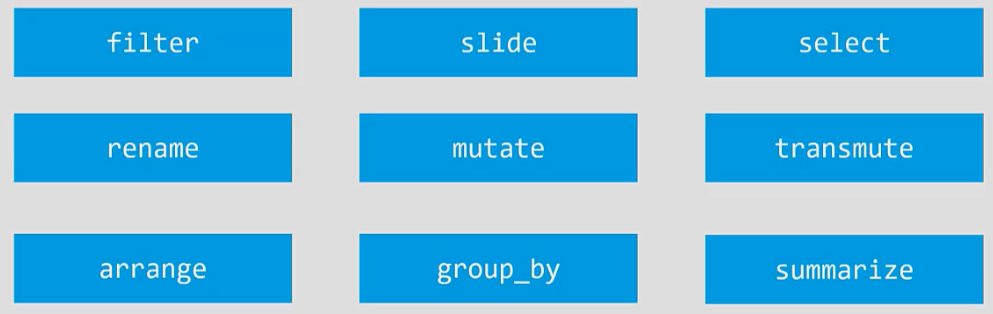

### Pipe concept

### Different types of pipes

- T Pipe '%T%'
- Compound assignment '%<>%'
- Exposition pipes '%S%'

#### Lets use the "mtcars" dataset

In [1]:
mtcars

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


### Regular pipe

#### Objective: 
- For Hp values > 120, compute the mean of all columns by cylinder type and in that table, create a new column 'kpl' by multiplying 'mpg' with 0.42.

In [2]:
library(tidyverse, warn.conflicts = F)

Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang
Registered S3 method overwritten by 'rvest':
  method            from
  read_xml.response xml2
-- Attaching packages --------------------------------------- tidyverse 1.2.1 --
v ggplot2 3.1.1       v purrr   0.3.2  
v tibble  2.1.1       v dplyr   0.8.0.1
v tidyr   0.8.3       v stringr 1.4.0  
v readr   1.3.1       v forcats 0.4.0  
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()


In [3]:
data_with_pipe <- mtcars %>% filter(hp>120) %>% group_by(cyl) %>% summarise_all(mean) %>% round(2) %>% transform(kpl = mpg * 0.42)

In [4]:
data_with_pipe

cyl,mpg,disp,hp,drat,wt,qsec,vs,am,gear,carb,kpl
6,18.9,160.07,140.33,3.82,3.22,17.57,0.67,0.33,4.33,4.67,7.938
8,15.1,353.10,209.21,3.23,4.00,16.77,0.00,0.14,3.29,3.50,6.342


### T - Pipe
- Useful to use when there are intermediate functions that return nothing. Like plots.

In [5]:
rnorm(10)

[1]  0.38806358  0.50901555  1.01988636 -0.03984361 -1.20977697 -0.88739082
 [7]  1.04337230  0.62830296 -0.35043441  0.67692161

[1] 2.582196

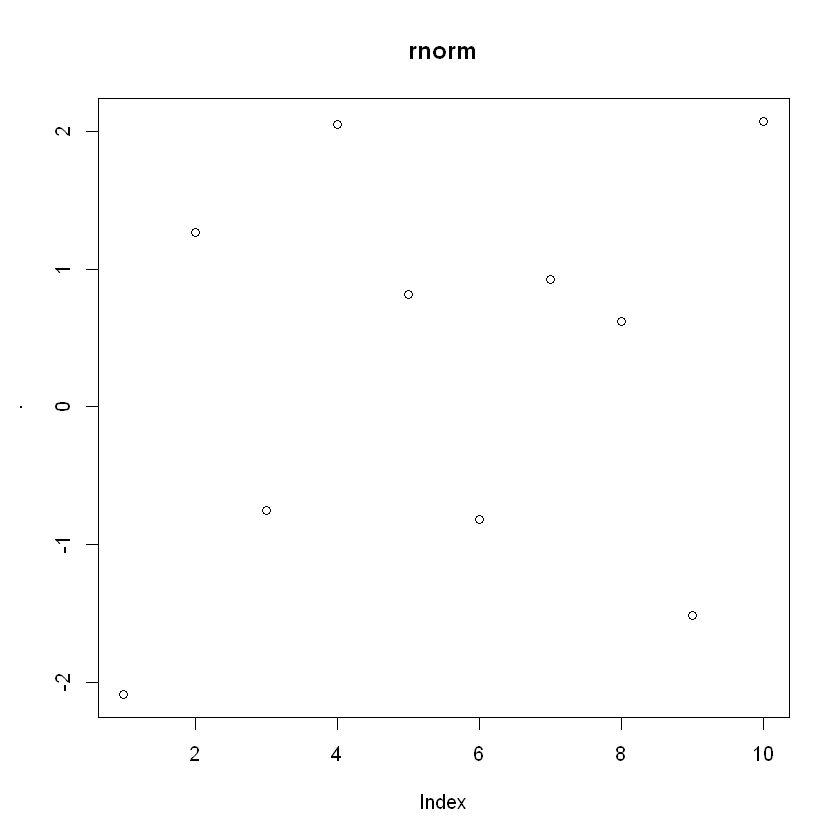

In [6]:
rnorm(10) %T>% plot(main = 'rnorm') %>% sum

### Compound assignement
- Helps perform calculations and assignments in one step

In [7]:
mtcars$mpg

[1] 21.0 21.0 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 17.8 16.4 17.3 15.2 10.4
[16] 10.4 14.7 32.4 30.4 33.9 21.5 15.5 15.2 13.3 19.2 27.3 26.0 30.4 15.8 19.7
[31] 15.0 21.4

In [8]:
mtcars$mpg %>% sqrt

[1] 4.582576 4.582576 4.774935 4.626013 4.324350 4.254409 3.781534 4.939636
 [9] 4.774935 4.381780 4.219005 4.049691 4.159327 3.898718 3.224903 3.224903
[17] 3.834058 5.692100 5.513620 5.822371 4.636809 3.937004 3.898718 3.646917
[25] 4.381780 5.224940 5.099020 5.513620 3.974921 4.438468 3.872983 4.626013

In [9]:
library(magrittr, warn.conflicts = F)

In [10]:
mtcars$mpg %<>% sqrt

In [11]:
mtcars$mpg

[1] 4.582576 4.582576 4.774935 4.626013 4.324350 4.254409 3.781534 4.939636
 [9] 4.774935 4.381780 4.219005 4.049691 4.159327 3.898718 3.224903 3.224903
[17] 3.834058 5.692100 5.513620 5.822371 4.636809 3.937004 3.898718 3.646917
[25] 4.381780 5.224940 5.099020 5.513620 3.974921 4.438468 3.872983 4.626013

### Exposition pipe operator
- Helps quickly access the columns in a dataframe

In [12]:
cor(mtcars$mpg, mtcars$cyl)

[1] -0.8585385

In [13]:
mtcars %$% sum(mpg, disp, cyl)

[1] 7723.013

#### Introduction to Tibble
- Faster
- Contains no row names
- Displays the data types

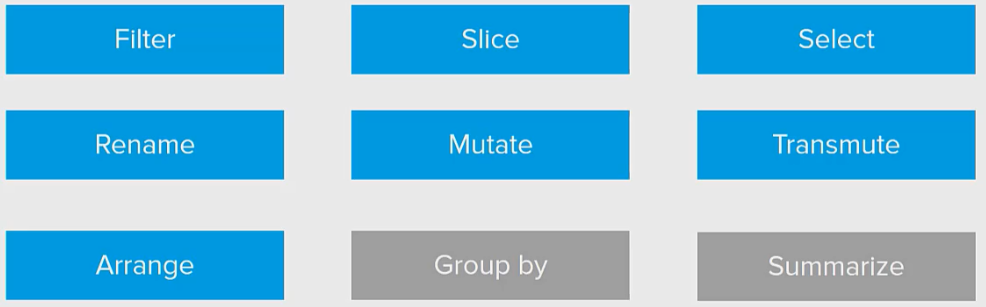

#### Creating a tibble object

In [14]:
class(mtcars)

[1] "data.frame"

In [15]:
mtcars

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2
Merc 280,4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [16]:
as_tibble(mtcars)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1
4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2
4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1
3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4
4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2
4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [17]:
mtcars_tibble <- as_tibble(mtcars)

In [18]:
print(mtcars_tibble)

# A tibble: 32 x 11
     mpg   cyl  disp    hp  drat    wt  qsec    vs    am  gear  carb
   <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
 1  4.58     6  160    110  3.9   2.62  16.5     0     1     4     4
 2  4.58     6  160    110  3.9   2.88  17.0     0     1     4     4
 3  4.77     4  108     93  3.85  2.32  18.6     1     1     4     1
 4  4.63     6  258    110  3.08  3.22  19.4     1     0     3     1
 5  4.32     8  360    175  3.15  3.44  17.0     0     0     3     2
 6  4.25     6  225    105  2.76  3.46  20.2     1     0     3     1
 7  3.78     8  360    245  3.21  3.57  15.8     0     0     3     4
 8  4.94     4  147.    62  3.69  3.19  20       1     0     4     2
 9  4.77     4  141.    95  3.92  3.15  22.9     1     0     4     2
10  4.38     6  168.   123  3.92  3.44  18.3     1     0     4     4
# ... with 22 more rows


In [19]:
class(mtcars_tibble)

[1] "tbl_df"     "tbl"        "data.frame"

### Data manipulation verbs

### filter

In [20]:
mtcars_tibble %>% filter(mpg > 5.0)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
5.692100,4,78.7,66,4.08,2.200,19.47,1,1,4,1
5.513620,4,75.7,52,4.93,1.615,18.52,1,1,4,2
5.822371,4,71.1,65,4.22,1.835,19.90,1,1,4,1
5.224940,4,79.0,66,4.08,1.935,18.90,1,1,4,1
5.099020,4,120.3,91,4.43,2.140,16.70,0,1,5,2
5.513620,4,95.1,113,3.77,1.513,16.90,1,1,5,2


In [21]:
mtcars_tibble %>% filter(gear == 4)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1
4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2
4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4
4.219005,6,167.6,123,3.92,3.440,18.90,1,0,4,4
5.692100,4,78.7,66,4.08,2.200,19.47,1,1,4,1
5.513620,4,75.7,52,4.93,1.615,18.52,1,1,4,2
5.822371,4,71.1,65,4.22,1.835,19.90,1,1,4,1


In [22]:
filter(mtcars_tibble, gear == 4)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1
4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2
4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4
4.219005,6,167.6,123,3.92,3.440,18.90,1,0,4,4
5.692100,4,78.7,66,4.08,2.200,19.47,1,1,4,1
5.513620,4,75.7,52,4.93,1.615,18.52,1,1,4,2
5.822371,4,71.1,65,4.22,1.835,19.90,1,1,4,1


In [23]:
filter(mtcars_tibble, mpg > 15.0)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb


In [24]:
filter(mtcars_tibble, cyl > 5, hp> 100)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2
4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1
3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4
4.219005,6,167.6,123,3.92,3.440,18.90,1,0,4,4
4.049691,8,275.8,180,3.07,4.070,17.40,0,0,3,3
4.159327,8,275.8,180,3.07,3.730,17.60,0,0,3,3


### Combining multiple conditions

### AND

In [25]:
filter(mtcars_tibble, (cyl > 5 & hp> 100))

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2
4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1
3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4
4.219005,6,167.6,123,3.92,3.440,18.90,1,0,4,4
4.049691,8,275.8,180,3.07,4.070,17.40,0,0,3,3
4.159327,8,275.8,180,3.07,3.730,17.60,0,0,3,3


### OR

In [26]:
filter(mtcars_tibble, (cyl > 5 | hp> 100))

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2
4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1
3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4
4.219005,6,167.6,123,3.92,3.440,18.90,1,0,4,4
4.049691,8,275.8,180,3.07,4.070,17.40,0,0,3,3
4.159327,8,275.8,180,3.07,3.730,17.60,0,0,3,3


### slice

In [27]:
slice(mtcars_tibble, 5:10)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.324350,8,360.0,175,3.15,3.44,17.02,0,0,3,2
4.254409,6,225.0,105,2.76,3.46,20.22,1,0,3,1
3.781534,8,360.0,245,3.21,3.57,15.84,0,0,3,4
4.939636,4,146.7,62,3.69,3.19,20.00,1,0,4,2
4.774935,4,140.8,95,3.92,3.15,22.90,1,0,4,2
4.381780,6,167.6,123,3.92,3.44,18.30,1,0,4,4


In [28]:
slice(mtcars_tibble, 1:2)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160,110,3.9,2.620,16.46,0,1,4,4
4.582576,6,160,110,3.9,2.875,17.02,0,1,4,4


### select

In [29]:
select(mtcars_tibble, mpg, disp)

mpg,disp
4.582576,160.0
4.582576,160.0
4.774935,108.0
4.626013,258.0
4.324350,360.0
4.254409,225.0
3.781534,360.0
4.939636,146.7
4.774935,140.8
4.381780,167.6


In [30]:
select(mtcars_tibble, disp, mpg)

disp,mpg
160.0,4.582576
160.0,4.582576
108.0,4.774935
258.0,4.626013
360.0,4.324350
225.0,4.254409
360.0,3.781534
146.7,4.939636
140.8,4.774935
167.6,4.381780


In [31]:
select(mtcars_tibble, -mpg, -gear, -cyl)

disp,hp,drat,wt,qsec,vs,am,carb
160.0,110,3.90,2.620,16.46,0,1,4
160.0,110,3.90,2.875,17.02,0,1,4
108.0,93,3.85,2.320,18.61,1,1,1
258.0,110,3.08,3.215,19.44,1,0,1
360.0,175,3.15,3.440,17.02,0,0,2
225.0,105,2.76,3.460,20.22,1,0,1
360.0,245,3.21,3.570,15.84,0,0,4
146.7,62,3.69,3.190,20.00,1,0,2
140.8,95,3.92,3.150,22.90,1,0,2
167.6,123,3.92,3.440,18.30,1,0,4


#### Selecting a range of columns

In [32]:
select(mtcars_tibble, mpg : vs)

mpg,cyl,disp,hp,drat,wt,qsec,vs
4.582576,6,160.0,110,3.90,2.620,16.46,0
4.582576,6,160.0,110,3.90,2.875,17.02,0
4.774935,4,108.0,93,3.85,2.320,18.61,1
4.626013,6,258.0,110,3.08,3.215,19.44,1
4.324350,8,360.0,175,3.15,3.440,17.02,0
4.254409,6,225.0,105,2.76,3.460,20.22,1
3.781534,8,360.0,245,3.21,3.570,15.84,0
4.939636,4,146.7,62,3.69,3.190,20.00,1
4.774935,4,140.8,95,3.92,3.150,22.90,1
4.381780,6,167.6,123,3.92,3.440,18.30,1


### rename

In [33]:
rename(mtcars_tibble, MPG = mpg, CYLINDERS = cyl)

MPG,CYLINDERS,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1
4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2
4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1
3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4
4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2
4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4


### Mutate

In [34]:
mutate(mtcars_tibble, KG = wt*1000)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,KG
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4,2620
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4,2875
4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1,2320
4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1,3215
4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2,3440
4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1,3460
3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4,3570
4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2,3190
4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2,3150
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4,3440


### transmute

In [35]:
transmute(mtcars_tibble, KG1 = wt*1000)

KG1
2620
2875
2320
3215
3440
3460
3570
3190
3150
3440


### arrange

#### Ascending order

In [36]:
mtcars_tibble

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1
4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2
4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1
3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4
4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2
4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [37]:
arrange(mtcars_tibble, wt)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
5.513620,4,95.1,113,3.77,1.513,16.90,1,1,5,2
5.513620,4,75.7,52,4.93,1.615,18.52,1,1,4,2
5.822371,4,71.1,65,4.22,1.835,19.90,1,1,4,1
5.224940,4,79.0,66,4.08,1.935,18.90,1,1,4,1
5.099020,4,120.3,91,4.43,2.140,16.70,0,1,5,2
5.692100,4,78.7,66,4.08,2.200,19.47,1,1,4,1
4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1
4.636809,4,120.1,97,3.70,2.465,20.01,1,0,3,1
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.438468,6,145.0,175,3.62,2.770,15.50,0,1,5,6


#### Descending order

In [38]:
arrange(mtcars_tibble, desc(wt))

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
3.224903,8,460.0,215,3.00,5.424,17.82,0,0,3,4
3.834058,8,440.0,230,3.23,5.345,17.42,0,0,3,4
3.224903,8,472.0,205,2.93,5.250,17.98,0,0,3,4
4.049691,8,275.8,180,3.07,4.070,17.40,0,0,3,3
4.381780,8,400.0,175,3.08,3.845,17.05,0,0,3,2
3.646917,8,350.0,245,3.73,3.840,15.41,0,0,3,4
3.898718,8,275.8,180,3.07,3.780,18.00,0,0,3,3
4.159327,8,275.8,180,3.07,3.730,17.60,0,0,3,3
3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4
3.872983,8,301.0,335,3.54,3.570,14.60,0,1,5,8


### Groupby and summarise

In [39]:
group_by(mtcars_tibble, cyl)

mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4
4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4
4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1
4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2
4.254409,6,225.0,105,2.76,3.460,20.22,1,0,3,1
3.781534,8,360.0,245,3.21,3.570,15.84,0,0,3,4
4.939636,4,146.7,62,3.69,3.190,20.00,1,0,4,2
4.774935,4,140.8,95,3.92,3.150,22.90,1,0,4,2
4.381780,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [40]:
cyl_group <- mtcars_tibble %>% group_by(cyl)

In [41]:
str(cyl_group)

Classes 'grouped_df', 'tbl_df', 'tbl' and 'data.frame':	32 obs. of  11 variables:
 $ mpg : num  4.58 4.58 4.77 4.63 4.32 ...
 $ cyl : num  6 6 4 6 8 6 8 4 4 6 ...
 $ disp: num  160 160 108 258 360 ...
 $ hp  : num  110 110 93 110 175 105 245 62 95 123 ...
 $ drat: num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ wt  : num  2.62 2.88 2.32 3.21 3.44 ...
 $ qsec: num  16.5 17 18.6 19.4 17 ...
 $ vs  : num  0 0 1 1 0 1 0 1 1 1 ...
 $ am  : num  1 1 1 0 0 0 0 0 0 0 ...
 $ gear: num  4 4 4 3 3 3 3 4 4 4 ...
 $ carb: num  4 4 1 1 2 1 4 2 2 4 ...
 - attr(*, "groups")=Classes 'tbl_df', 'tbl' and 'data.frame':	3 obs. of  2 variables:
  ..$ cyl  : num  4 6 8
  ..$ .rows:List of 3
  .. ..$ : int  3 8 9 18 19 20 21 26 27 28 ...
  .. ..$ : int  1 2 4 6 10 11 30
  .. ..$ : int  5 7 12 13 14 15 16 17 22 23 ...
  ..- attr(*, ".drop")= logi TRUE


In [42]:
cyl_group %>% summarise(average_hp = mean(hp))

cyl,average_hp
4,82.63636
6,122.28571
8,209.21429


- 2nd method.

In [43]:
mtcars_tibble %>% group_by(cyl) %>% summarise(average_hp = mean(hp))

cyl,average_hp
4,82.63636
6,122.28571
8,209.21429


In [44]:
mtcars_tibble %>% group_by(gear) %>% summarise(Average_HP = mean(hp))

gear,Average_HP
3,176.1333
4,89.5000
5,195.6000


In [45]:
mtcars_tibble %>% group_by(cyl) %>% summarise(Average_Wt = mean(wt))

cyl,Average_Wt
4,2.285727
6,3.117143
8,3.999214


In [46]:
mtcars_tibble %>% group_by(cyl) %>% summarise(Avg_MPG = mean(mpg))

cyl,Avg_MPG
4,5.147091
6,4.440690
8,3.872129


### Types of joins in dplyr

#### There are 6 different joins in dplyr

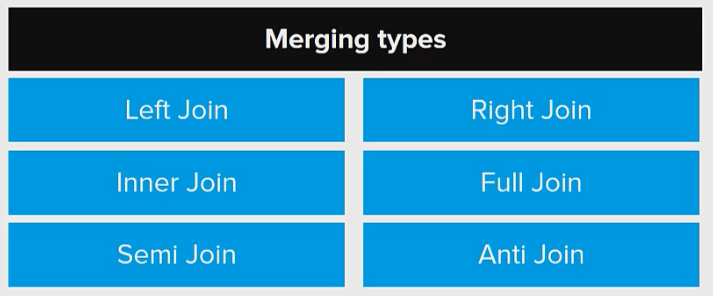

#### Creating sample dataframes 

In [47]:
df1 <- data.frame(StudentId = c(101:106), 
                 Subject = c("Hindi", "English", 
                             "Maths", "Science", 
                             "Political Science", 
                             "Physics"))
df1 

StudentId,Subject
101,Hindi
102,English
103,Maths
104,Science
105,Political Science
106,Physics


In [48]:
df2 <- data.frame(StudentId = c(102, 104, 106,
                               107, 108), 
                 State = c("Mangalore", "Mysore",
                           "Pune", "Dehradun", "Delhi")) 
df2 

StudentId,State
102,Mangalore
104,Mysore
106,Pune
107,Dehradun
108,Delhi


### Left join

- If there are common column names, no need to name the joining column
- If there is no common columns, we have to explicitly specify the the column

In [49]:
left_join(df1, df2)

Joining, by = "StudentId"


StudentId,Subject,State
101,Hindi,NA
102,English,Mangalore
103,Maths,NA
104,Science,Mysore
105,Political Science,NA
106,Physics,Pune


### Right join

In [50]:
right_join(df1, df2)

Joining, by = "StudentId"


StudentId,Subject,State
102,English,Mangalore
104,Science,Mysore
106,Physics,Pune
107,NA,Dehradun
108,NA,Delhi


### Inner join

In [51]:
inner_join(df1, df2)

Joining, by = "StudentId"


StudentId,Subject,State
102,English,Mangalore
104,Science,Mysore
106,Physics,Pune


### Full join

In [52]:
full_join(df1, df2)

Joining, by = "StudentId"


StudentId,Subject,State
101,Hindi,NA
102,English,Mangalore
103,Maths,NA
104,Science,Mysore
105,Political Science,NA
106,Physics,Pune
107,NA,Dehradun
108,NA,Delhi


### Semi join
- Returns all rows from left that are in common with right, but only keeps columns in the left table

In [53]:
semi_join(df1, df2)

Joining, by = "StudentId"


StudentId,Subject
102,English
104,Science
106,Physics


### Anti join
- Returns all rows from left that are not in common with right, but only keeps columns in the left table

In [54]:
anti_join(df1, df2)

Joining, by = "StudentId"


StudentId,Subject
101,Hindi
103,Maths
105,Political Science
